# VehicleBody Response — SineSweep

**목적**: 사인스윕 조향 입력에 대한 차체 응답(속도, 롤/피치/요, heave) 확인.

## 1. 환경 설정

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = Path().resolve().parents[3]
sys.path.insert(0, str(ROOT_DIR))

CONFIG_PATH = ROOT_DIR / "vehicle_sim" / "models" / "params" / "vehicle_standard.yaml"
CORNERS = ["FL", "FR", "RL", "RR"]

## 2. 모듈 로드 및 초기화

In [2]:
from vehicle_sim.models.vehicle_body.vehicle_body import VehicleBody
from vehicle_sim.scenarios.sinesweep import generate

scenario = generate()
n = len(scenario["time"])
t = scenario["time"]

body = VehicleBody(config_path=str(CONFIG_PATH))
scenario.apply_initial_conditions(body)

Scenario generated from log: CM_Body_sinesweep.csv, steps=55001, t_end=55.000s


## 3. 시뮬레이션

In [3]:
log = {key: np.zeros(n) for key in (
    "vx", "vy",
    "roll", "roll_rate",
    "pitch", "pitch_rate",
    "yaw", "yaw_rate",
    "heave",
    "steer_ref_fl", "steer_ref_fr",
    "steer_act_fl", "steer_act_fr",
    "steer_trq_fl", "steer_trq_fr",
)}

initial_ref = scenario.driver.reference(0)
log["vx"][0]          = body.state.velocity_x
log["vy"][0]          = body.state.velocity_y
log["roll"][0]        = np.degrees(body.state.roll)
log["roll_rate"][0]   = np.degrees(body.state.roll_rate)
log["pitch"][0]       = np.degrees(body.state.pitch)
log["pitch_rate"][0]  = np.degrees(body.state.pitch_rate)
log["yaw"][0]         = np.degrees(body.state.yaw)
log["yaw_rate"][0]    = np.degrees(body.state.yaw_rate)
log["heave"][0]       = body.state.heave * 1e3
log["steer_ref_fl"][0] = np.degrees(initial_ref["FL"])
log["steer_ref_fr"][0] = np.degrees(initial_ref["FR"])
log["steer_act_fl"][0] = np.degrees(body.corners["FL"].state.steering_angle)
log["steer_act_fr"][0] = np.degrees(body.corners["FR"].state.steering_angle)

for i in range(1, n):
    dt  = max(t[i] - t[i - 1], 1e-6)
    idx = i - 1

    corner_inputs = scenario.corner_inputs(idx=idx, body=body)
    steer_ref     = scenario.driver.reference(idx)

    body.update(dt, corner_inputs)

    state = body.state
    log["vx"][i]           = state.velocity_x
    log["vy"][i]           = state.velocity_y
    log["roll"][i]         = np.degrees(state.roll)
    log["roll_rate"][i]    = np.degrees(state.roll_rate)
    log["pitch"][i]        = np.degrees(state.pitch)
    log["pitch_rate"][i]   = np.degrees(state.pitch_rate)
    log["yaw"][i]          = np.degrees(state.yaw)
    log["yaw_rate"][i]     = np.degrees(state.yaw_rate)
    log["heave"][i]        = state.heave * 1e3
    log["steer_ref_fl"][i] = np.degrees(steer_ref["FL"])
    log["steer_ref_fr"][i] = np.degrees(steer_ref["FR"])
    log["steer_act_fl"][i] = np.degrees(body.corners["FL"].state.steering_angle)
    log["steer_act_fr"][i] = np.degrees(body.corners["FR"].state.steering_angle)
    log["steer_trq_fl"][i] = scenario["steer_trq"]["FL"][idx]
    log["steer_trq_fr"][i] = scenario["steer_trq"]["FR"][idx]

print("Simulation complete")

Simulation complete


## 4. 결과 시각화

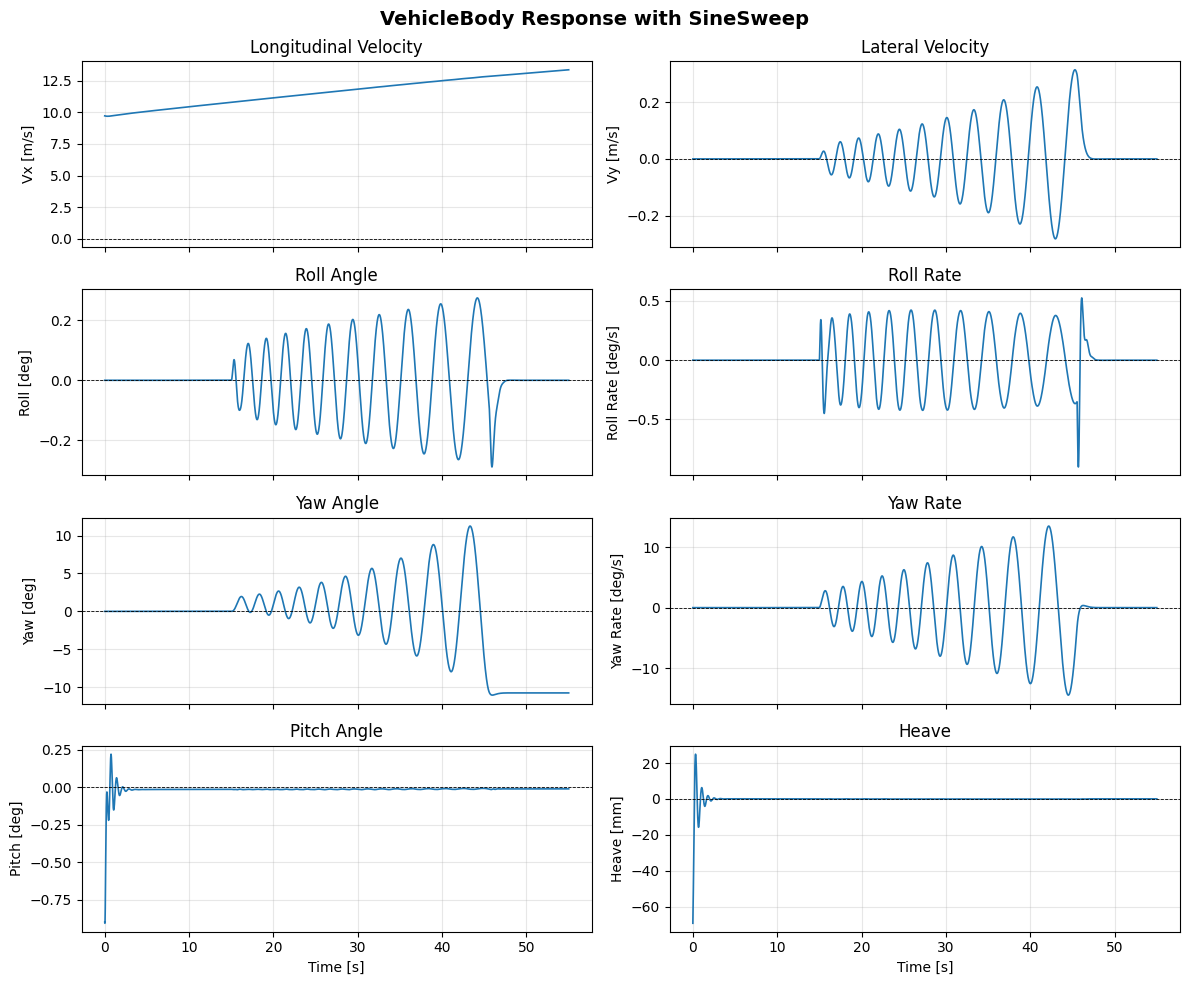

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
fig.suptitle("VehicleBody Response with SineSweep", fontsize=14, fontweight="bold")

plots = [
    (axes[0, 0], log["vx"],        "Vx [m/s]",        "Longitudinal Velocity"),
    (axes[0, 1], log["vy"],        "Vy [m/s]",        "Lateral Velocity"),
    (axes[1, 0], log["roll"],      "Roll [deg]",      "Roll Angle"),
    (axes[1, 1], log["roll_rate"], "Roll Rate [deg/s]","Roll Rate"),
    (axes[2, 0], log["yaw"],       "Yaw [deg]",       "Yaw Angle"),
    (axes[2, 1], log["yaw_rate"],  "Yaw Rate [deg/s]","Yaw Rate"),
    (axes[3, 0], log["pitch"],     "Pitch [deg]",     "Pitch Angle"),
    (axes[3, 1], log["heave"],     "Heave [mm]",      "Heave"),
]

for ax, values, ylabel, title in plots:
    ax.plot(t, values, lw=1.2)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.axhline(0.0, color="k", lw=0.6, ls="--")

for ax in axes[-1]:
    ax.set_xlabel("Time [s]")

fig.tight_layout()
plt.show()